In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

c:\Users\27726\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\27726\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
file_path = "data/asteroid.csv"
df = pd.read_csv(file_path)

C:\Users\27726\AppData\Local\Temp\ipykernel_26292\3299639776.py:2: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
print("--- Step 1: Data Cleaning ---")
non_predictive = ['id', 'name', 'full_name', 'pdes', 'prefix']
df = df.drop(columns=[col for col in non_predictive if col in df.columns], errors='ignore')
df = df.dropna(subset=['diameter'])
df.drop_duplicates(inplace=True)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:", df.isnull().sum().sum())

--- Step 1: Data Cleaning ---
Missing values remaining: 0


C:\Users\27726\AppData\Local\Temp\ipykernel_26292\266987355.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


In [4]:
print("\n--- Step 2: Categorical Encoding ---")
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

if len(df) > 100000:
    df = df.sample(n=100000, random_state=42).reset_index(drop=True)


--- Step 2: Categorical Encoding ---


In [5]:
print("\n--- Step 3: Feature Selection ---")
X = df.drop('diameter', axis=1)
y = df['diameter']

rf_selector = RandomForestRegressor(n_estimators=20, max_depth=10, n_jobs=-1, random_state=42)
rf_selector.fit(X, y)

importances = rf_selector.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
selected_features = X.columns[indices[:top_n]].tolist()

print("Selected Features to use for modeling:", selected_features)
X_selected = X[selected_features]


--- Step 3: Feature Selection ---
Selected Features to use for modeling: ['H', 'albedo', 'spkid', 'tp_cal', 'e', 'n', 'per', 'om', 'a', 'tp']



--- Step 4: Plotting Selected Features Importance ---


C:\Users\27726\AppData\Local\Temp\ipykernel_26292\1609352785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


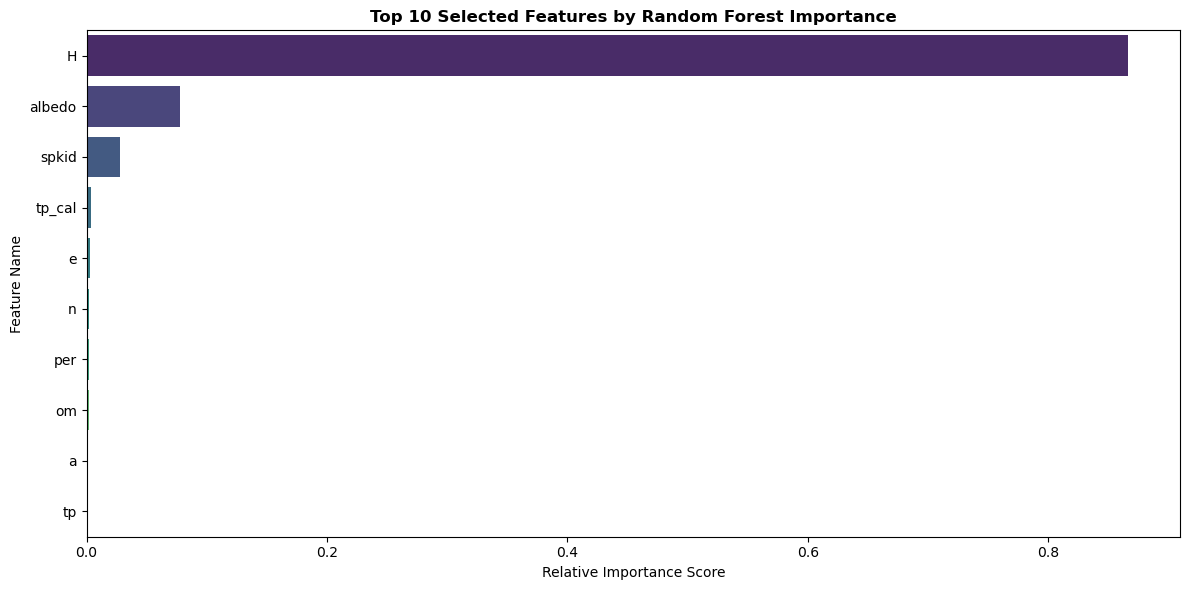

In [6]:
print("\n--- Step 4: Plotting Selected Features Importance ---")
plt.figure(figsize=(12, 6))
sns.barplot(
    x=importances[indices[:top_n]], 
    y=X.columns[indices[:top_n]], 
    palette="viridis"
)
plt.title('Top 10 Selected Features by Random Forest Importance', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [7]:
print("\n--- Step 6: Train/Test Dataset Split ---")
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y, 
    test_size=0.2, 
    random_state=42
)


--- Step 6: Train/Test Dataset Split ---


In [8]:
print("\n--- Step 5: Feature Scaling ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Step 5: Feature Scaling ---


In [9]:
print("\n--- Step 7: Fitting Decision Tree Regressor ---")
model = DecisionTreeRegressor(
    max_depth=4,            
    min_samples_leaf=5, 
    random_state=42
)
model.fit(X_train_scaled, y_train)


--- Step 7: Fitting Decision Tree Regressor ---


DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)

In [10]:
print("\n--- Step 8: Evaluating Model Performance ---")
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:.4f} km")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error:    {rmse:.4f} km")
print(f"R2 Score (Variance ratio):  {r2:.4f}")


--- Step 8: Evaluating Model Performance ---
Mean Absolute Error (MAE):  1.3846 km
Mean Squared Error (MSE):   13.2205
Root Mean Squared Error:    3.6360 km
R2 Score (Variance ratio):  0.8427



--- Step 9: Plotting Decision Tree Structures ---


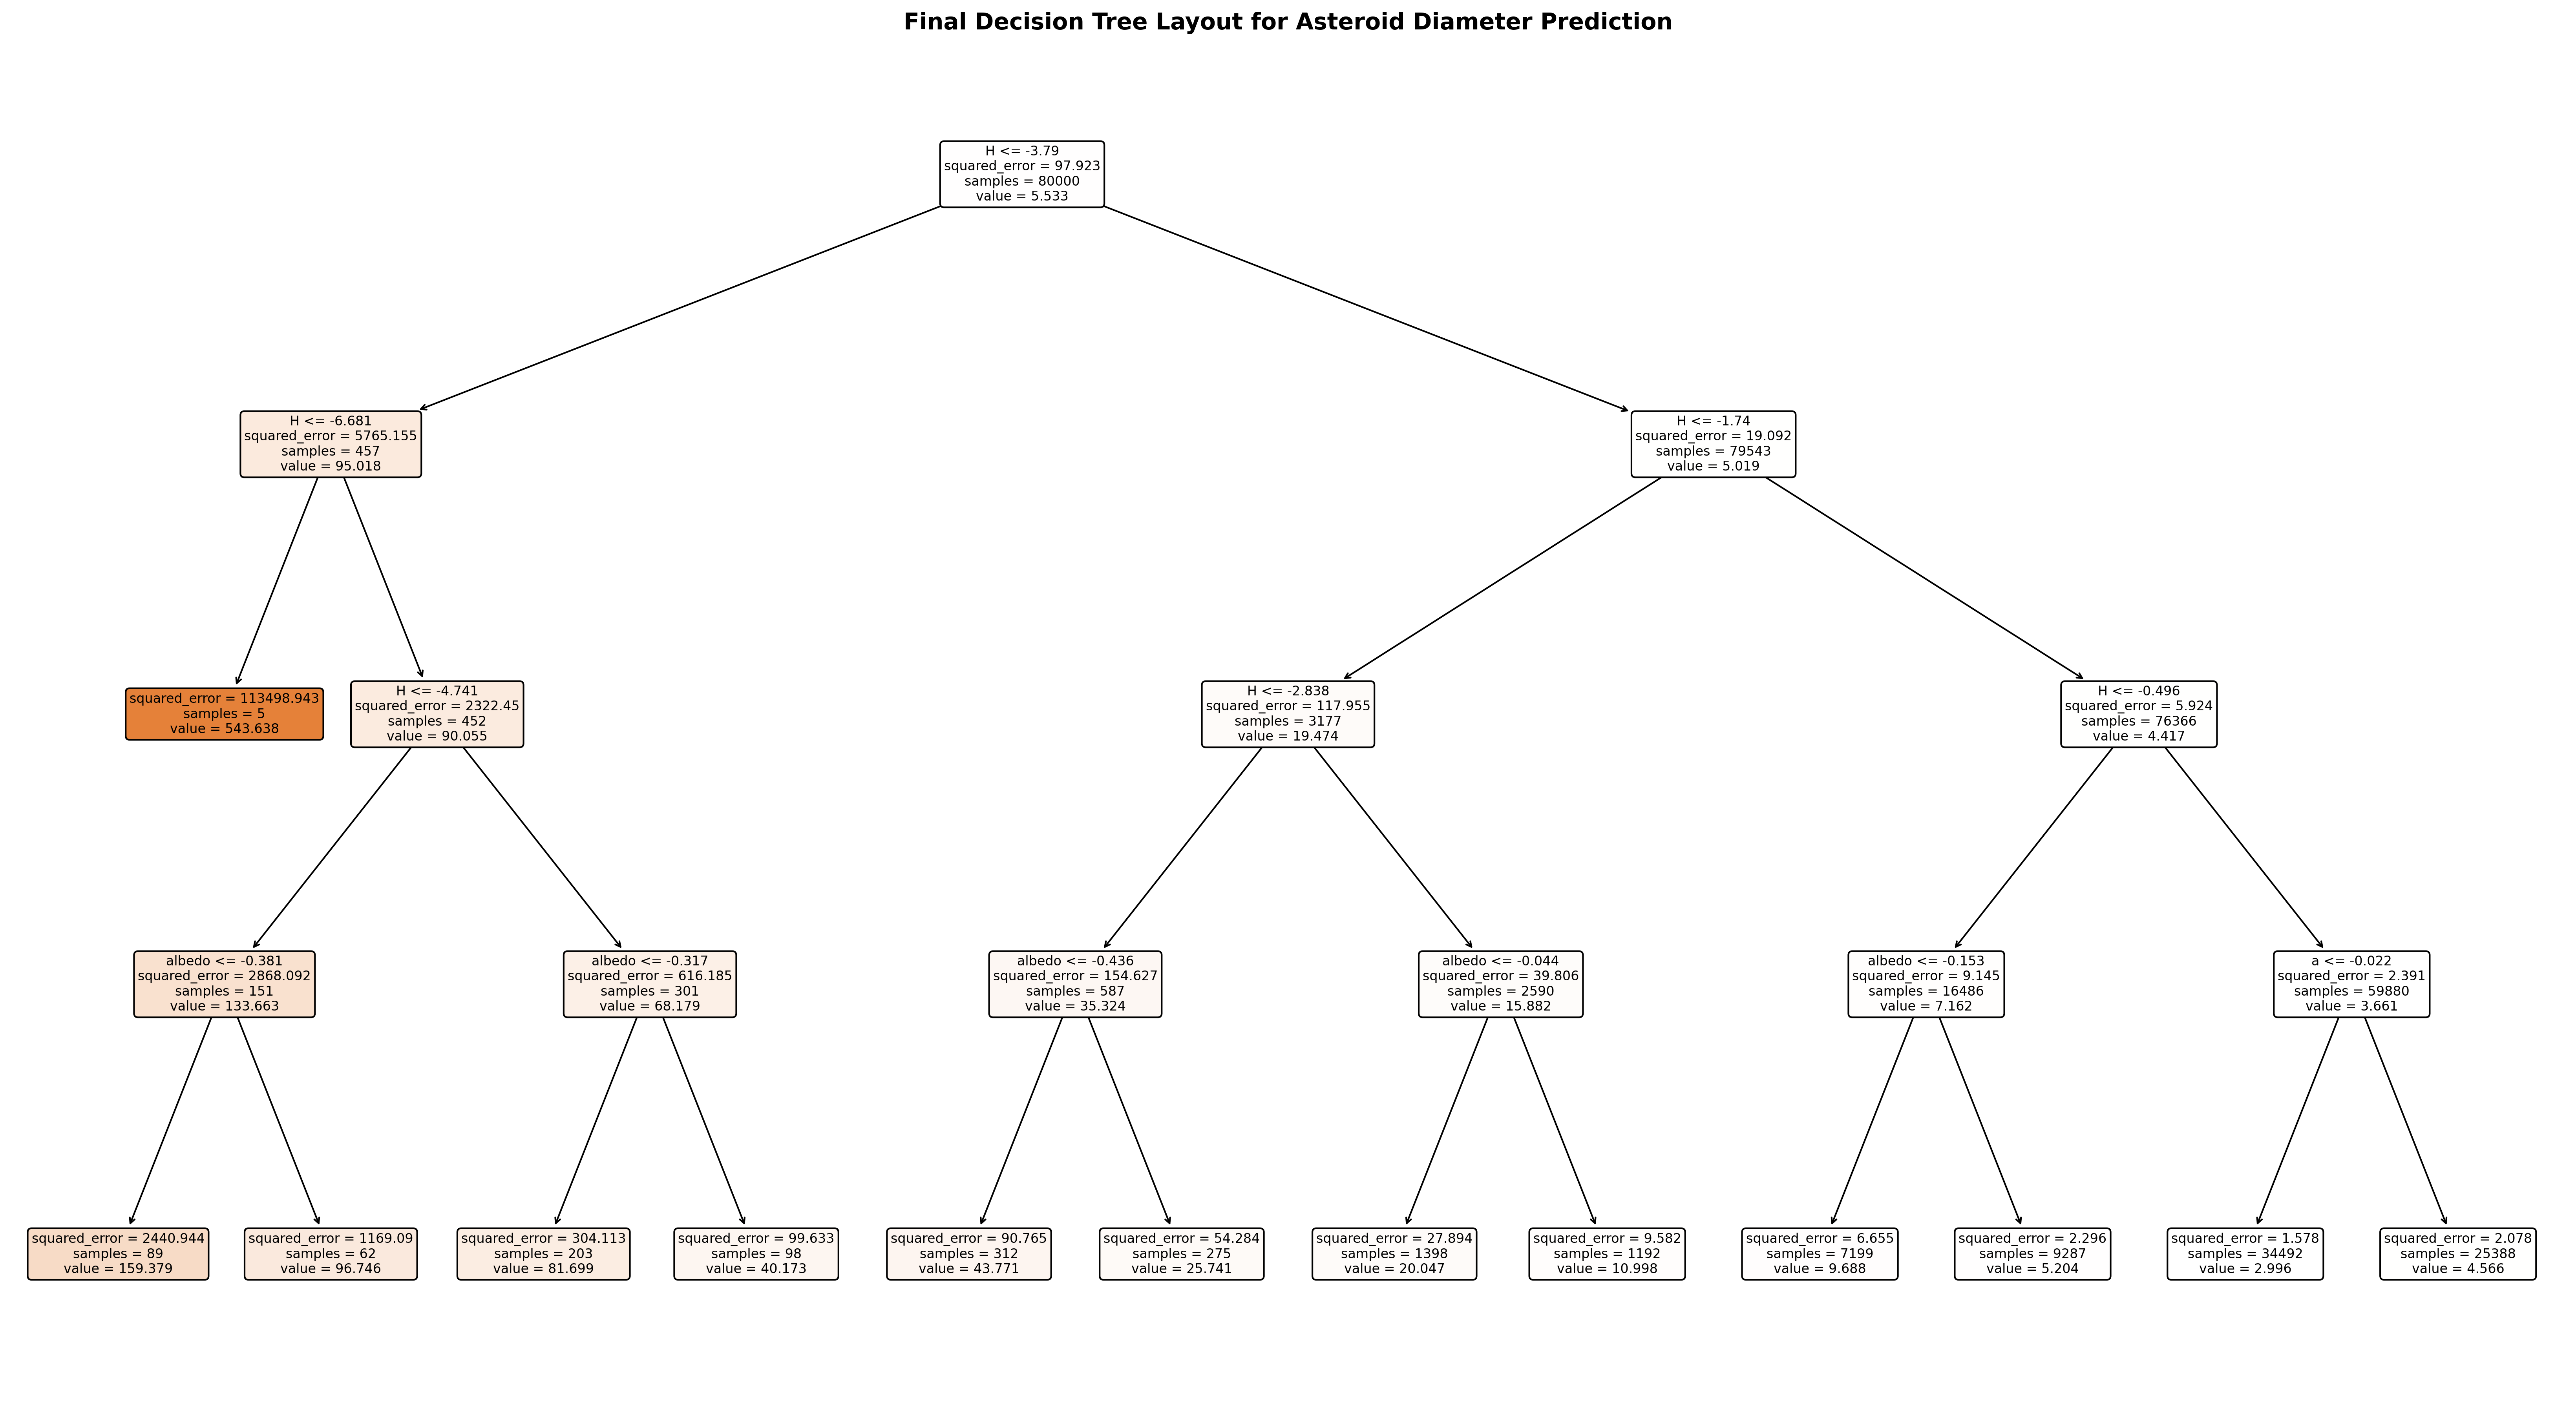

In [11]:
print("\n--- Step 9: Plotting Decision Tree Structures ---")
plt.figure(figsize=(22, 12), dpi=300) 
plot_tree(
    model,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Final Decision Tree Layout for Asteroid Diameter Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()